In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.legend_handler import HandlerTuple
import subprocess
import os

matplotlib.rcParams.update({"axes.grid": True, "font.size": 15})
# matplotlib.rcParams.keys()

In [3]:
def readmetadata(fname):
    on = False
    lines = ""
    with open(fname) as file:
        for line in file:
            idx = line.find("Hamiltonian")
            if idx != -1:
                on = True
            if on and line.find("--") == -1 and line.find("[") == -1:
                lines += line
            idx = line.find("Seed")
            if idx != -1:
                on = False
                break
    meta_dict = {"Description": lines}
    return meta_dict

def valErr_format(val, err):
    if err > 0:
        place = int(np.floor(np.log10(err)))
        
        # Handle the edge case where rounding bumps it to the next power of 10 (e.g., 0.98 -> 1.0)
        if round(err, -place) >= 10**(place + 1):
            place += 1    
        decimals = max(0, -place)
        err_rounded = round(err, -place)
        val_rounded = round(val, -place)
    else:
        decimals = 3  # Fallback if error is exactly 0
        err_rounded = 0.0
        val_rounded = val

    return f"{val_rounded:.{decimals}f} ± {err_rounded:.{decimals}f}"

{'Description': 'Hamiltonian               : LennardJonesHO\nWF Train Type             : EllipticGaussian\nWaveFunction              : LJGaussian\nSolver                    : MetropolisHastings\npreferAnalytic            : true\ndimensions (D)            : 3\nparticles (N)             : 6\nmin_dist                  : 1\nmax_radius                : 1e+06\nomega                     : 0.111803\nomega_z                   : 0.027951\nLJsigma                   : 1\nLJenEps                   : 1\nLJalpha                   : 1\nLJGaussian_loc_Ken_method : 0\nrep_a_factor              : 0.05\nrep_strength              : inf\nmaxStrength               : 1\ntime Step                 : 0.1\nEquilibr. Steps           : 50000\nBFGS MC Steps             : 1000000\nBFGS_tol                  : 1e-05\nFinal MC Steps            : 2^23 (8388608)\nMesh MC Steps             : 2^21 (2097152)\nNhid                      : 10\nActivation Func           : tanh\nLearning Rate             : 0.05\nPretrain Steps   

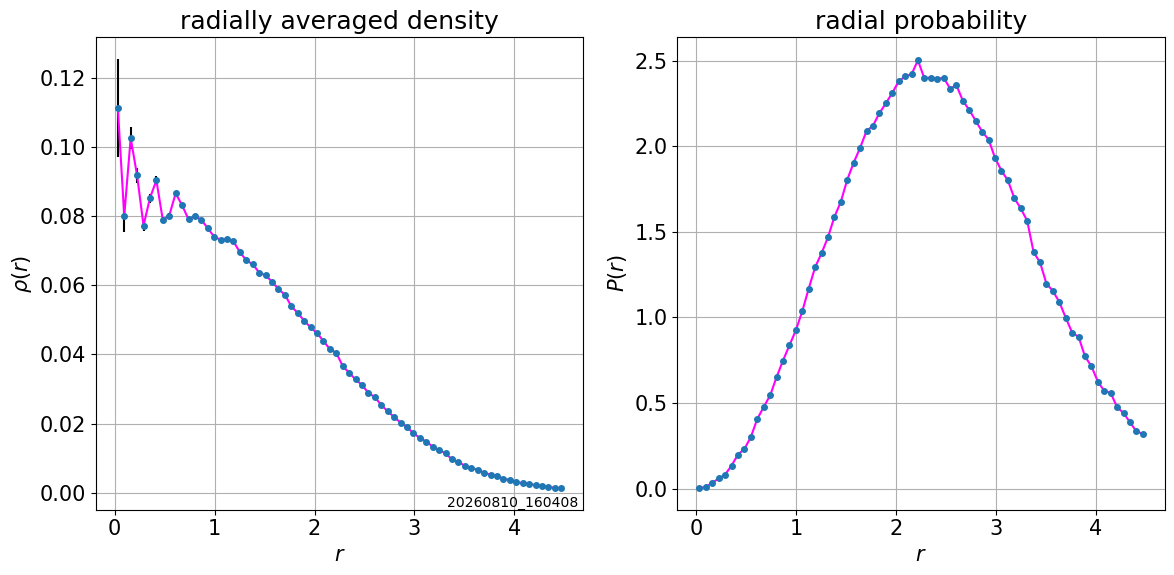

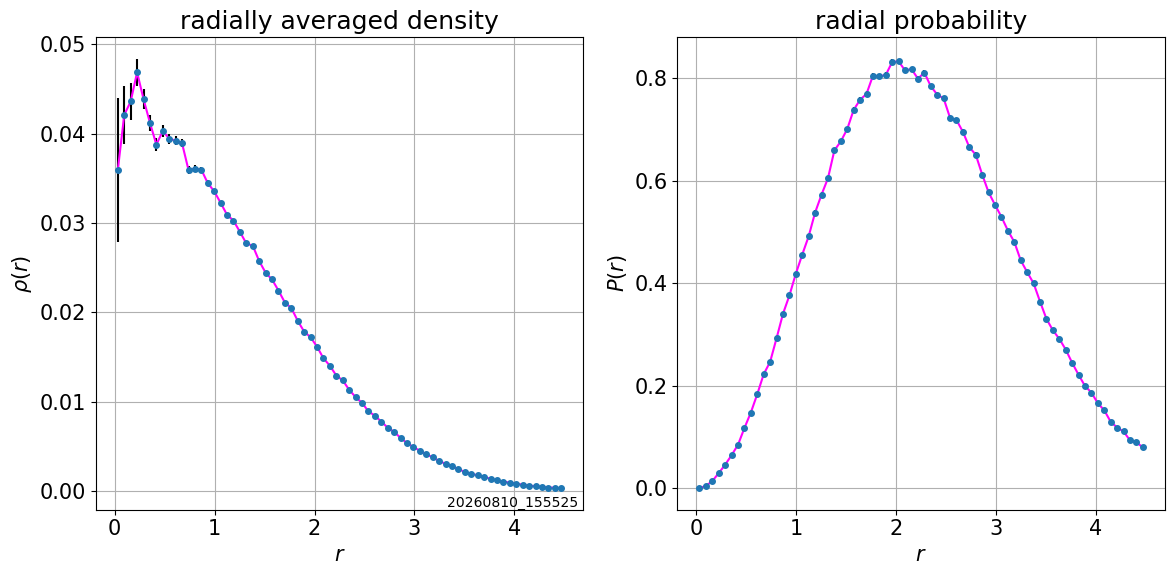

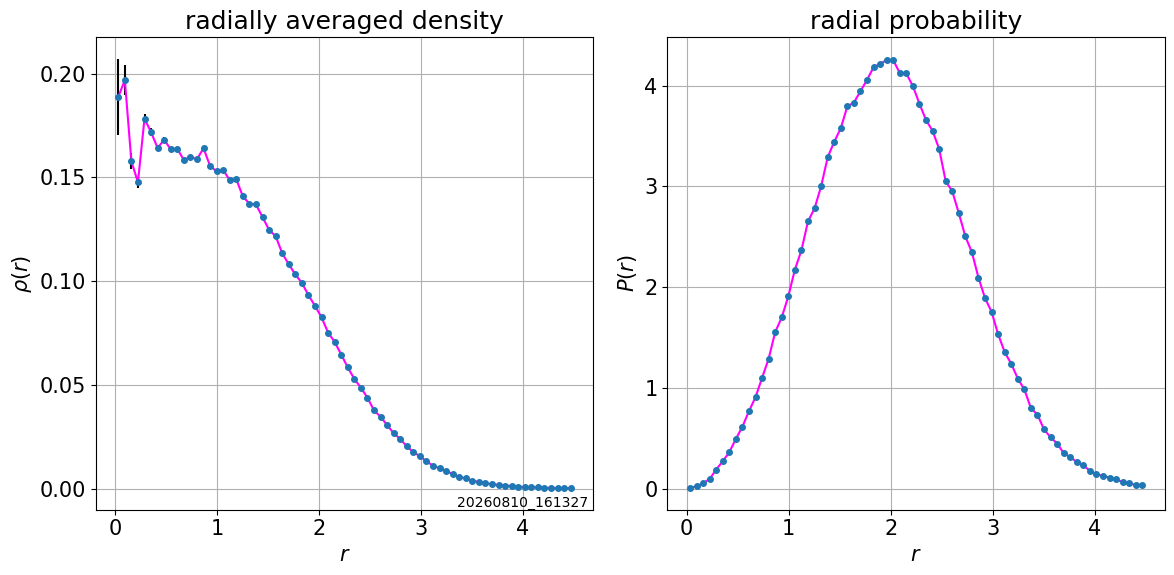

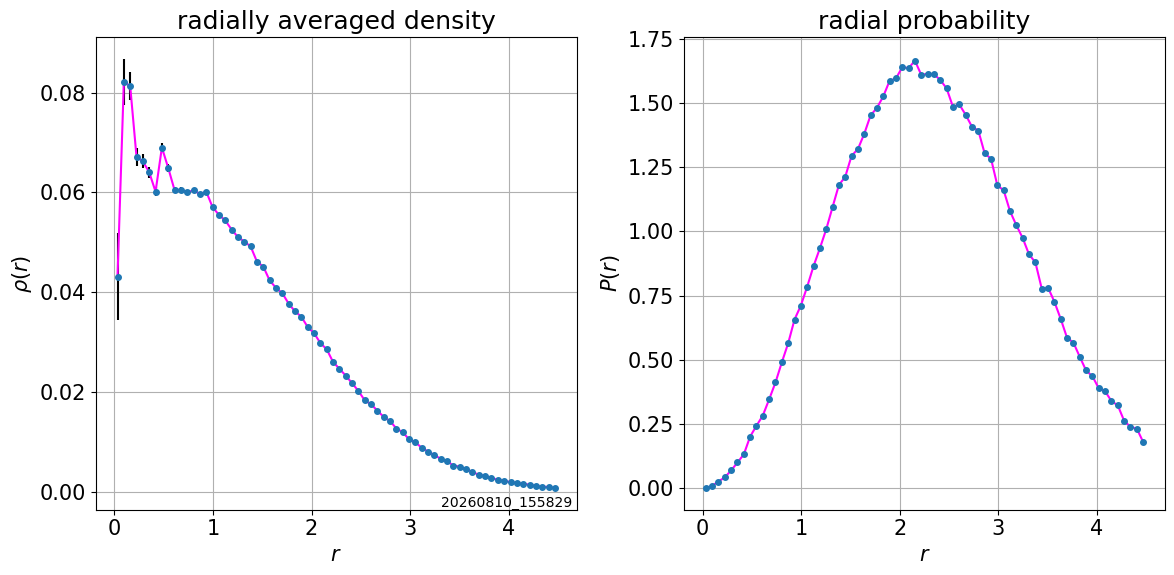

In [11]:
%matplotlib inline

def volume_hshpere(r, dim):
    return 2 * np.pi**(dim/2) / sp.special.gamma(dim/2) * r**(dim-1)

fdir = "./logs_OBD"
directory = os.fsencode(fdir)
for file in os.listdir(directory):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        fname = filename
        totfname = f"{fdir}/{fname}"

        dim = 3
        r, rho, drho, p, dp = np.loadtxt(totfname, delimiter=',', unpack=True)

        fig = plt.figure(figsize=(12, 6))
        gs = fig.add_gridspec(1, 2)

        ax = fig.add_subplot(gs[0, 0])
        ax.errorbar(r, y=rho, yerr=drho, color='magenta', ecolor='black',
                    marker='.', markersize=8, linestyle='-', mfc="tab:blue", mec="tab:blue")
        ax.set_title(r"radially averaged density")
        ax.set_ylabel(r"$\rho(r)$")
        ax.set_xlabel(r"$r$")
        ax.text(0.99, 0, fname[4:len(fname)-4], transform=ax.transAxes, fontsize=10, ha="right", va="bottom")

        ax = fig.add_subplot(gs[0, 1])
        ax.errorbar(r, y=p, yerr=dp, color='magenta', ecolor='black',
                    marker='.', markersize=8, linestyle='-', mfc="tab:blue", mec="tab:blue")
        # ax.errorbar(r, y=rad_rho, yerr=drad_rho, color='red', ecolor='black',
        #             marker='x', markersize=8, linestyle='--', mfc="tab:green", mec="tab:green", alpha=0.4)
        ax.set_title(r"radial probability")
        ax.set_ylabel(r"$P(r)$")
        ax.set_xlabel(r"$r$")
        fig.tight_layout()
        md = readmetadata(f"logs/{fname[:-4]}.log")
        print(md)
        fig.savefig(f"figs_OBD/OBD_{fname[4:len(fname)-4]}.png", dpi=300, metadata=md)

{'Description': 'Hamiltonian               : LennardJonesHO\nWF Train Type             : EllipticGaussian\nWaveFunction              : LJGaussian\nSolver                    : MetropolisHastings\npreferAnalytic            : true\ndimensions (D)            : 3\nparticles (N)             : 2\nmin_dist                  : 1\nmax_radius                : 1e+06\nomega                     : 0.111803\nomega_z                   : 0.027951\nLJsigma                   : 1\nLJenEps                   : 1\nLJalpha                   : 1\nLJGaussian_loc_Ken_method : 0\nrep_a_factor              : 0.05\nrep_strength              : inf\nmaxStrength               : 1\ntime Step                 : 0.85\nEquilibr. Steps           : 50000\nBFGS MC Steps             : 1000000\nBFGS_tol                  : 1e-05\nFinal MC Steps            : 2^23 (8388608)\nMesh MC Steps             : 2^20 (1048576)\nNhid                      : 10\nActivation Func           : tanh\nLearning Rate             : 0.05\nPretrain Steps  

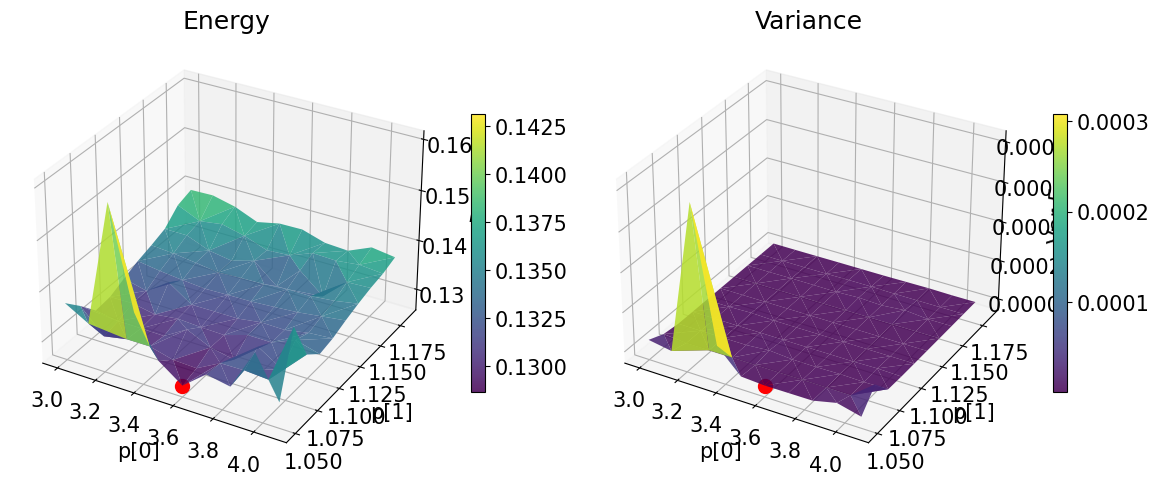

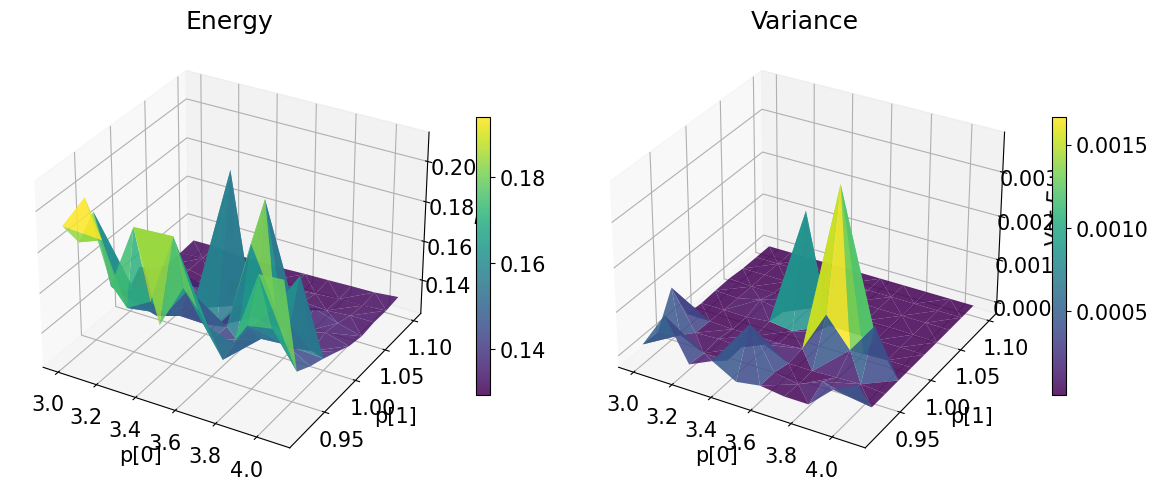

In [9]:
%matplotlib inline

fdir = "./parameter_mesh"
directory = os.fsencode(fdir)
for file in os.listdir(directory):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        fname = filename
        totfname = f"{fdir}/{fname}"

        mesh = np.loadtxt(totfname, delimiter=',')
        nPar = mesh.shape[1] - 2

        if nPar == 1:
            fig = plt.figure(figsize=(12, 6))
            gs = fig.add_gridspec(1, 2)

            ax = fig.add_subplot(gs[0, 0])
            ax.errorbar(mesh[:,0], y=mesh[:,-2], yerr=mesh[:,-1], color='magenta', ecolor='black',
                        marker='.', markersize=8, linestyle='-', mfc="tab:blue", mec="tab:blue")
            ax.set_title(r"Energy")
            ax.set_ylabel(r"$E$")
            ax.set_xlabel(f"p[0]")
            ax.text(0.99, 0, fname[4:len(fname)-4], transform=ax.transAxes, fontsize=10, ha="right", va="bottom")

            ax = fig.add_subplot(gs[0, 1])
            ax.errorbar(mesh[:,0], y=mesh[:,-1]**2, color='magenta', ecolor='black',
                        marker='.', markersize=8, linestyle='-', mfc="tab:blue", mec="tab:blue")
            ax.set_title(r"Variance")
            ax.set_ylabel(r"Var $E$")
            ax.set_xlabel(f"p[0]")
        elif nPar == 2:
            # fig = plt.figure(figsize=(12, 6))

            # ax = fig.add_subplot(121, projection='3d')
            # sc = ax.scatter(mesh[:,0], mesh[:,1], mesh[:,-2], c=mesh[:,-2], cmap='viridis', s=30)
            # # mark minimum
            # min_idx = np.argmin(mesh[:,-2])
            # ax.scatter(mesh[min_idx,0], mesh[min_idx,1], mesh[min_idx,-2], color='red', s=100, zorder=5)
            # ax.set_title(r"Energy")
            # ax.set_zlabel(r"$E$")
            # ax.set_xlabel(f"p[0]")
            # ax.set_ylabel(f"p[1]")
            # # ax.text(0.99, 0, fname[4:len(fname)-4], transform=ax.transAxes, fontsize=10, ha="right", va="bottom", s=30)
            # plt.colorbar(sc, ax=ax, shrink=0.5)

            # ax = fig.add_subplot(122, projection='3d')
            # sc = ax.scatter(mesh[:,0], mesh[:,1], mesh[:,-1]**2, c=mesh[:,-1]**2, cmap='viridis', s=30)
            # ax.scatter(mesh[min_idx,0], mesh[min_idx,1], mesh[min_idx,-1]**2, color='red', s=100, zorder=5)
            # ax.set_title(r"Variance")
            # ax.set_zlabel(r"Var $E$")
            # ax.set_xlabel(f"p[0]")
            # ax.set_ylabel(f"p[1]")
            # plt.colorbar(sc, ax=ax, shrink=0.5)

            fig = plt.figure(figsize=(12, 6))
            min_idx = np.argmin(mesh[:,-2])

            ax = fig.add_subplot(121, projection='3d')
            # Replace scatter with plot_trisurf
            surf = ax.plot_trisurf(mesh[:,0], mesh[:,1], mesh[:,-2], cmap='viridis', edgecolor='none', alpha=0.85)
            # Mark minimum
            ax.scatter(mesh[min_idx,0], mesh[min_idx,1], mesh[min_idx,-2], color='red', s=100, zorder=5)
            ax.set_title(r"Energy")
            ax.set_zlabel(r"$E$")
            ax.set_xlabel(f"p[0]")
            ax.set_ylabel(f"p[1]")
            plt.colorbar(surf, ax=ax, shrink=0.5) # Pass 'surf' instead of 'sc'

            ax = fig.add_subplot(122, projection='3d')
            surf_var = ax.plot_trisurf(mesh[:,0], mesh[:,1], mesh[:,-1]**2, cmap='viridis', edgecolor='none', alpha=0.85)
            ax.scatter(mesh[min_idx,0], mesh[min_idx,1], mesh[min_idx,-1]**2, color='red', s=100, zorder=5)
            ax.set_title(r"Variance")
            ax.set_zlabel(r"Var $E$")
            ax.set_xlabel(f"p[0]")
            ax.set_ylabel(f"p[1]")
            plt.colorbar(surf_var, ax=ax, shrink=0.5)
        else:
            min_idx = np.argmin(mesh[:,-2])
            okIdx_arr = []
            countRows = 0
            for par in range(nPar):
                okIdx = []
                mask = np.ones(mesh.shape[0], dtype=bool)
                for j in range(nPar):
                    if j != par:
                        mask &= np.isclose(mesh[:, j], mesh[min_idx, j])
                
                okIdx = np.where(mask)[0]
                okIdx_arr.append(okIdx)
                if okIdx.size > 1:
                    countRows += 1

            if countRows == 2:
                # varied_params = [par for par, okIdx in enumerate(okIdx_arr) if okIdx.size > 1]
                # p_x, p_y = varied_params[0], varied_params[1]

                # fig = plt.figure(figsize=(12, 6))
                # ax = fig.add_subplot(121, projection='3d')
                # sc = ax.scatter(mesh[:,p_x], mesh[:,p_y], mesh[:,-2], c=mesh[:,-2], cmap='viridis', s=30)
                # # mark minimum
                # min_idx = np.argmin(mesh[:,-2])
                # ax.scatter(mesh[min_idx,p_x], mesh[min_idx,p_y], mesh[min_idx,-2], color='red', s=100, zorder=5)
                # ax.set_title(r"Energy")
                # ax.set_zlabel(r"$E$")
                # ax.set_xlabel(f"p[{p_x}]")
                # ax.set_ylabel(f"p[{p_y}]")
                # # ax.text(0.99, 0, fname[4:len(fname)-4], transform=ax.transAxes, fontsize=10, ha="right", va="bottom", s=30)
                # plt.colorbar(sc, ax=ax, shrink=0.5)

                # ax = fig.add_subplot(122, projection='3d')
                # sc = ax.scatter(mesh[:,p_x], mesh[:,p_y], mesh[:,-1]**2, c=mesh[:,-1]**2, cmap='viridis', s=30)
                # ax.scatter(mesh[min_idx,p_x], mesh[min_idx,p_y], mesh[min_idx,-1]**2, color='red', s=100, zorder=5)
                # ax.set_title(r"Variance")
                # ax.set_zlabel(r"Var $E$")
                # ax.set_xlabel(f"p[{p_x}]")
                # ax.set_ylabel(f"p[{p_y}]")
                # plt.colorbar(sc, ax=ax, shrink=0.5)
                varied_params = [par for par, okIdx in enumerate(okIdx_arr) if okIdx.size > 1]
                p_x, p_y = varied_params[0], varied_params[1]

                fig = plt.figure(figsize=(12, 6))
                min_idx = np.argmin(mesh[:,-2])
                
                ax = fig.add_subplot(121, projection='3d')
                # Replace scatter with plot_trisurf
                surf = ax.plot_trisurf(mesh[:,p_x], mesh[:,p_y], mesh[:,-2], cmap='viridis', edgecolor='none', alpha=0.85)
                # mark minimum
                ax.scatter(mesh[min_idx,p_x], mesh[min_idx,p_y], mesh[min_idx,-2], color='red', s=100, zorder=5)
                ax.set_title(r"Energy")
                ax.set_zlabel(r"$E$")
                ax.set_xlabel(f"p[{p_x}]")
                ax.set_ylabel(f"p[{p_y}]")
                plt.colorbar(surf, ax=ax, shrink=0.5) # Pass 'surf' instead of 'sc'

                ax = fig.add_subplot(122, projection='3d')
                surf_var = ax.plot_trisurf(mesh[:,p_x], mesh[:,p_y], mesh[:,-1]**2, cmap='viridis', edgecolor='none', alpha=0.85)
                ax.scatter(mesh[min_idx,p_x], mesh[min_idx,p_y], mesh[min_idx,-1]**2, color='red', s=100, zorder=5)
                ax.set_title(r"Variance")
                ax.set_zlabel(r"Var $E$")
                ax.set_xlabel(f"p[{p_x}]")
                ax.set_ylabel(f"p[{p_y}]")
                plt.colorbar(surf_var, ax=ax, shrink=0.5)
            else:
                fig = plt.figure(figsize=(12, 6 * countRows))
                gs = fig.add_gridspec(countRows, 2)
                it = 0
                for par in range(nPar):
                    okIdx = okIdx_arr[par]
                    if okIdx.size <= 1:
                        continue

                    ax = fig.add_subplot(gs[it, 0])
                    ax.errorbar(mesh[okIdx,par], y=mesh[okIdx,-2], yerr=mesh[okIdx,-1], color='magenta', ecolor='black',
                                marker='.', markersize=8, linestyle='-', mfc="tab:blue", mec="tab:blue")
                    ax.set_title(r"Energy")
                    ax.set_ylabel(r"$E$")
                    ax.set_xlabel(f"p[{par}]")
                    ax.text(0.99, 0, fname[4:len(fname)-4], transform=ax.transAxes, fontsize=10, ha="right", va="bottom")

                    ax = fig.add_subplot(gs[it, 1])
                    ax.errorbar(mesh[okIdx,par], y=mesh[okIdx,-1]**2, color='magenta', ecolor='black',
                                marker='.', markersize=8, linestyle='-', mfc="tab:blue", mec="tab:blue")
                    ax.set_title(r"Variance")
                    ax.set_ylabel(r"Var $E$")
                    ax.set_xlabel(f"p[{par}]")
                    
                    it += 1

        fig.tight_layout()
        md = readmetadata(f"logs/{fname[:-4]}.log")
        print(md)
        fig.savefig(f"figs_mesh/plot_{fname[4:len(fname)-4]}.png", dpi=300, metadata=md)

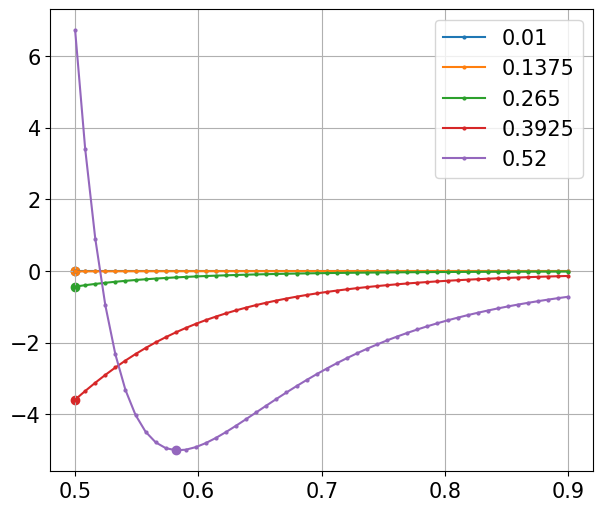

In [6]:
fig = plt.figure(figsize=(7,6))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

enEps = 5
omega = 1
r = np.linspace(0.5, stop=0.9)
sigma = np.linspace(start=0.01, stop=0.52, num=5)
for i in range(sigma.size):
    var = (sigma[i] / r)**6
    V = 4 * enEps * var * (var - 1)
    rmin = np.argmin(V)
    ax.errorbar(r, V, marker='.', markersize=4, label=sigma[i])
    ax.scatter(r[rmin], V[rmin])
ax.legend()

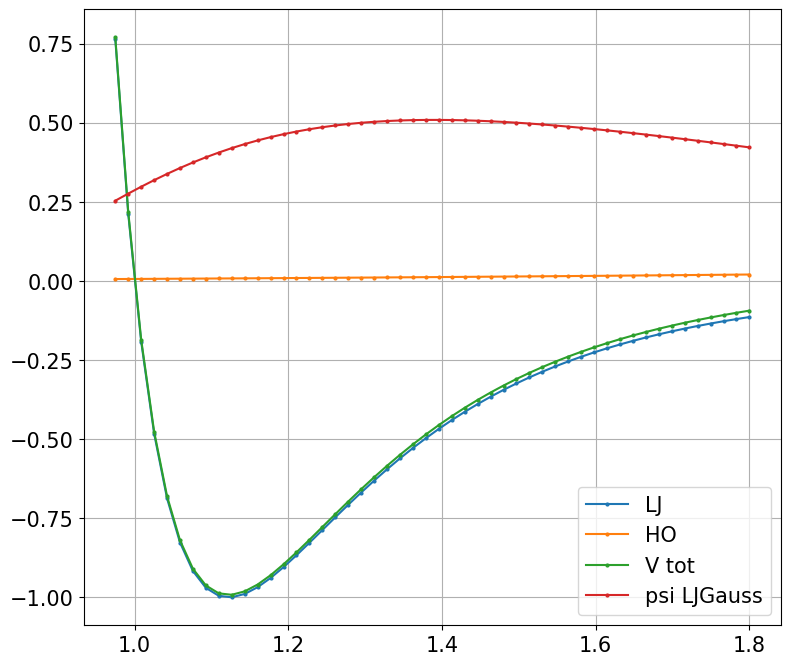

In [7]:
fig = plt.figure(figsize=(9,8))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

enEps = 1
omega = 1
r = np.linspace(0.975, stop=1.8)
sigma = 1
var = (sigma / r)**6
LJ = 4 * enEps * var * (var - 1)
omega = 0.111803
HO = 0.5 * omega**2 * r**2
V = LJ + HO
alpha = 4
LJGauss = np.exp(-1/(2 * alpha) * r**2 - 0.5 * (sigma/r)**5)
# rmin = np.argmin(V)
ax.errorbar(r, LJ, marker='.', markersize=4, label="LJ")
ax.errorbar(r, HO, marker='.', markersize=4, label="HO")
ax.errorbar(r, V, marker='.', markersize=4, label="V tot")
ax.errorbar(r, LJGauss**2, marker='.', markersize=4, label="psi LJGauss")
# ax.scatter(r[rmin], V[rmin])
ax.legend()